<a href="https://colab.research.google.com/github/yanmar83/FnctnSTEP/blob/main/TP/01_Step1fnctn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$10^{14}
$

In [1]:
import math

def tabla_comparativa_10_14_corregida():
    print("="*120)
    print("  COMPARATIVA 10^14 ")
    print("  Corrección: Datos reales ajustados a su valor verdadero (Orden de 10^11)")
    print("="*120)

    #  1. CONSTANTES DE ENTRADA (DATOS REALES VERIFICADOS) ---
    x = 10**14

    # PI(X) EXACTO en 10^14 (OEIS A000720)
    PI_X_EXACTO = 3204941750802

    # Conteos exactos de Pares en 10^14 (Fuente: T. Oliveira e Silva)
    # NOTA: valores correctos (aprox 1.35 x 10^11)
    datos = [
        {"nombre": "Gap 4 (Primos)", "real": 135780264890, "k": 1.0},
        {"nombre": "Gap 6 (Sexies)", "real": 271561334425, "k": 2.0},
        {"nombre": "Gap 8",          "real": 135780789895, "k": 1.0},
        {"nombre": "Gap 10",         "real": 181040687802, "k": 4/3},
        {"nombre": "Gap 12",         "real": 271561069479, "k": 2.0},
        {"nombre": "Gap 14",         "real": 162936729495, "k": 6/5}
    ]

    # 2. CÁLCULO DE PARÁMETROS
    ln_x_half = math.log(x / 2.0)
    ln_2x     = math.log(2.0 * x)
    termino_geo = 1.0 - (ln_x_half / ln_2x)

    C2 = 0.6601618158

    # 3. REFERENCIA HARDY-LITTLEWOOD -
    log_x = math.log(x)
    hl_base = 2 * C2 * (x / (log_x**2))

    # 4. GENERACIÓN DE TABLA -
    print(f"{'TIPO (GAP)':<15} | {'REAL (OEIS)':<18} | {'HARDY-LITTLEWOOD':<22} | {'Mi Modelo':<24} | {'ERROR %':<10}")
    print("-" * 120)

    for d in datos:
        nombre = d['nombre']
        real = d['real']
        k = d['k']

        # A. -Hardy-Littlewood
        val_hl = hl_base * k
        err_hl = ((val_hl - real) / real) * 100

        # B. FÓRMULA (Usando PI_X_EXACTO)
        val_tuya = PI_X_EXACTO * termino_geo * k
        err_tuya = ((val_tuya - real) / real) * 100

        # Formateo
        def fmt_num(n): return f"{int(n):,}"
        def fmt_err(e): return f"{e:+.4f}%"

        print(f"{nombre:<15} | {fmt_num(real):<18} | {fmt_num(val_hl):<12} ({fmt_err(err_hl)}) | {fmt_num(val_tuya):<12} ({fmt_err(err_tuya)}) | {fmt_err(err_tuya)}")

    print("-" * 120)
    print(f"VALOR DEL TÉRMINO GEOMÉTRICO (10^14): {termino_geo:.8f}")

if __name__ == "__main__":
    tabla_comparativa_10_14_corregida()

  COMPARATIVA 10^14 
  Corrección: Datos reales ajustados a su valor verdadero (Orden de 10^11)
TIPO (GAP)      | REAL (OEIS)        | HARDY-LITTLEWOOD       | Mi Modelo                | ERROR %   
------------------------------------------------------------------------------------------------------------------------
Gap 4 (Primos)  | 135,780,264,890    | 127,055,347,326 (-6.4258%) | 134,925,051,082 (-0.6299%) | -0.6299%
Gap 6 (Sexies)  | 271,561,334,425    | 254,110,694,653 (-6.4260%) | 269,850,102,164 (-0.6301%) | -0.6301%
Gap 8           | 135,780,789,895    | 127,055,347,326 (-6.4261%) | 134,925,051,082 (-0.6302%) | -0.6302%
Gap 10          | 181,040,687,802    | 169,407,129,769 (-6.4259%) | 179,900,068,109 (-0.6300%) | -0.6300%
Gap 12          | 271,561,069,479    | 254,110,694,653 (-6.4259%) | 269,850,102,164 (-0.6300%) | -0.6300%
Gap 14          | 162,936,729,495    | 152,466,416,792 (-6.4260%) | 161,910,061,298 (-0.6301%) | -0.6301%
---------------------------------------------

$10^{15}$


In [2]:
import mpmath

# para cálculos internos
mpmath.mp.dps = 50

# 1. DATOS REALES
# Valor EXACTO de Pi(x) para 10^15 (Fuente::: Oliveira e Silva)

PI_X_REAL_15 = 29844570422669

# Conteos reales de pares en 10^15 (Fuente::: OEIS)
real_counts_10_15 = {
    2:  1177209242304,   # Twin Primes
    4:  1177208491858,   # Cousin
    6:  2354417142430,   # Sexy (x2)
    8:  1177208682148,
    10: 1569611234977,   # (x1.33)
    12: 2354417933939,   # (x2)
    14: 1412651090765    # (x1.2)
}

# 2. PREPARACIÓN DE CONSTANTES C2 ---
C2 = mpmath.mpf('0.66016181584686957392781211001455577843262336028473')

def get_gap_constant(g):
    """Calcula el multiplicador para Gaps > 2 (Hardy-Littlewood k-tuples)"""
    multiplier = mpmath.mpf(1)
    if g % 3 == 0: multiplier *= mpmath.mpf(2)      # x2
    if g % 5 == 0: multiplier *= mpmath.mpf(4)/3    # x1.33
    if g % 7 == 0: multiplier *= mpmath.mpf(6)/5    # x1.2
    return C2 * multiplier

# 3 MODELO
def Mi_Modelo(x_val, pix_val, gap):
    # x_val   = 10^15
    # pix_val = 29,844,570,422,669 (DATO REAL)

    Ck = get_gap_constant(gap)

#

    base_density = (mpmath.mpf(pix_val) ** 2) / x_val
    prediccion = 2 * Ck * base_density


    return prediccion

# 4 EJECUCIÓN -
print(f"ANÁLISIS DE GAPS EN 10^15 (Usando Pi(x) Real)")
print(f"Pi(10^15) utilizado: {PI_X_REAL_15:,}")
print("="*105)
print(f"{'GAP':<4} | {'REAL (10^15)':<20} | {'Mi MODELO':<20} | {'DIFERENCIA':<15} | {'ERROR %':<10}")
print("="*105)

x = mpmath.power(10, 15)

for gap in [2, 4, 6, 8, 10, 12, 14]:
    real = real_counts_10_15[gap]

    # Pasamos x, pi(x) real y el gap
    estimado = Mi_Modelo(x, PI_X_REAL_15, gap)

    diff = estimado - real
    error = (diff / real) * 100

    signo = "+" if error > 0 else ""

    # Convierte a nativos de Python para evitar el TypeError
    print(f"{gap:<4} | {int(real):<20,d} | {int(estimado):<20,d} | {int(diff):<+15,d} | {signo}{float(error):.4f}%")

print("="*105)

ANÁLISIS DE GAPS EN 10^15 (Usando Pi(x) Real)
Pi(10^15) utilizado: 29,844,570,422,669
GAP  | REAL (10^15)         | Mi MODELO            | DIFERENCIA      | ERROR %   
2    | 1,177,209,242,304    | 1,176,010,124,728    | -1,199,117,575  | -0.1019%
4    | 1,177,208,491,858    | 1,176,010,124,728    | -1,198,367,129  | -0.1018%
6    | 2,354,417,142,430    | 2,352,020,249,457    | -2,396,892,972  | -0.1018%
8    | 1,177,208,682,148    | 1,176,010,124,728    | -1,198,557,419  | -0.1018%
10   | 1,569,611,234,977    | 1,568,013,499,638    | -1,597,735,338  | -0.1018%
12   | 2,354,417,933,939    | 2,352,020,249,457    | -2,397,684,481  | -0.1018%
14   | 1,412,651,090,765    | 1,411,212,149,674    | -1,438,941,090  | -0.1019%


$10^{16}$


In [3]:
import math

def tabla_li_x_autonoma():
    print("="*120)
    print("  COMPARATIVA EN 10^16: (MOTOR Li(x))")
    print("  Objetivo: Probar la fórmula sin conocer el conteo real de primos y comparar con H-L")
    print("="*120)

    # 1. DATOS REALES (OEIS)
    datos = [
        {"nombre": "Gap 4 (Primos)", "real": 10304191659848, "k": 1.0},
        {"nombre": "Gap 6 (Sexies)", "real": 20608350916773, "k": 2.0},
        {"nombre": "Gap 8",          "real": 10304204411440, "k": 1.0},
        {"nombre": "Gap 10",         "real": 13738917764136, "k": 4/3},
        {"nombre": "Gap 12",         "real": 20608335324821, "k": 2.0},
        {"nombre": "Gap 14",         "real": 12365042657301, "k": 6/5}
    ]

    # 2.: Li(x) -
    x = 10**16

    # Valor precalculado para Li(10^16)
    LI_X = 279238344248552.0

    # 3 geom.
    ln_x_half = math.log(x / 2.0)
    ln_2x     = math.log(2.0 * x)
    termino_geo = 1.0 - (ln_x_half / ln_2x)

    # 4. HARDY-LITTLEWOOD
    log_x = math.log(x)
    hl_base_clasica = 2 * 0.6601618158 * (x / (log_x**2))

    # 5. IMPRESIÓN
    # Actualiza las cabeceras para que entren ambas columnas
    print(f"{'TIPO (GAP)':<15} | {'REAL (OEIS)':<18} | {'HARDY-LITTLEWOOD':<23} | {'Mi Modelo (Li)':<24} | {'ERROR % (Mi Modelo)':<10}")
    print("-" * 125)

    for d in datos:
        nombre = d['nombre']
        real = d['real']
        k = d['k']

        # A. CÁLCULO HARDY-LITTLEWOOD
        val_hl = hl_base_clasica * k
        err_hl = ((val_hl - real) / real) * 100

        # B. CÁLCULO DE MI PROPUESTA
        val_tuya_li = LI_X * termino_geo * k
        err_tuya = ((val_tuya_li - real) / real) * 100

        # Formateo
        def fmt_num(n): return f"{int(n):,}"
        def fmt_err(e): return f"{e:+.4f}%"

        # Imprime la fila completa, incluyendo el valor y error de Hardy-Littlewood
        print(f"{nombre:<15} | {fmt_num(real):<18} | {fmt_num(val_hl):<13} ({fmt_err(err_hl)}) | {fmt_num(val_tuya_li):<13}  | {fmt_err(err_tuya)}")

    print("-" * 125)
    print(f"Base usada Li(10^16): {int(LI_X):,}")
    print(f"Diferencia Li(x) vs Pi(x) real: +{int(LI_X - 279238341033925):,} primos")
    print("="*125)

if __name__ == "__main__":
    tabla_li_x_autonoma()

  COMPARATIVA EN 10^16: (MOTOR Li(x))
  Objetivo: Probar la fórmula sin conocer el conteo real de primos y comparar con H-L
TIPO (GAP)      | REAL (OEIS)        | HARDY-LITTLEWOOD        | Mi Modelo (Li)           | ERROR % (Mi Modelo)
-----------------------------------------------------------------------------------------------------------------------------
Gap 4 (Primos)  | 10,304,191,659,848 | 9,727,675,029,711 (-5.5950%) | 10,313,350,454,629  | +0.0889%
Gap 6 (Sexies)  | 20,608,350,916,773 | 19,455,350,059,422 (-5.5948%) | 20,626,700,909,259  | +0.0890%
Gap 8           | 10,304,204,411,440 | 9,727,675,029,711 (-5.5951%) | 10,313,350,454,629  | +0.0888%
Gap 10          | 13,738,917,764,136 | 12,970,233,372,948 (-5.5949%) | 13,751,133,939,506  | +0.0889%
Gap 12          | 20,608,335,324,821 | 19,455,350,059,422 (-5.5948%) | 20,626,700,909,259  | +0.0891%
Gap 14          | 12,365,042,657,301 | 11,673,210,035,653 (-5.5951%) | 12,376,020,545,555  | +0.0888%
----------------------------

G(N)


In [1]:
import numpy as np

def calcular_error_relativo():
    # --- BASE DE DATOS EXACTA ---
    # Fuente: OEIS A000040 (pi) y A007508 (pi_2)
    # Formato: (Potencia de 10, pi(x)_real, pi_2(x)_gemelos_real)
    data = [
        (6,  78498,             8169),
        (7,  664579,            58980),
        (8,  5761455,           440312),
        (9,  50847534,          3424506),
        (10, 455052511,         27412679),
        (11, 4118054813,        224376048),
        (12, 37607912018,       1870585220),
        (13, 346065536839,      15834664872),
        (14, 3204941750802,     135780321665),
        (15, 29844570422669,    1177209242304),
        (16, 279238341033925,   10304195697298),
        (17, 2623557157654233,  90948832723613),  # Dato calculado por T. Oliveira e Silva
        (18, 24739954287740860, 808675888577436)  # Dato calculado por Prime Pages
    ]

    print(f"{'10^x':<5} | {'Gemelos Real':<20} | {'Tu Fórmula':<20} | {'Diferencia':<12} | {'Error Relativo':<15}")
    print("-" * 85)

    errores = []

    for power, pi_x, pi2_real in data:
        x = 10**power

        #  FÓRMULA ---
        # V = pi(x) * [ 1 - (ln(x/2) / ln(2x)) ]

        ln_x_half = np.log(x / 2.0)
        ln_2x     = np.log(2.0 * x)

        # El término entre paréntesis
        parentesis = 1.0 - (ln_x_half / ln_2x)

        # Cálculo final
        estimacion_usuario = pi_x * parentesis

        # --- CÁLCULO DE ERROR ---
        diferencia = estimacion_usuario - pi2_real
        error_rel = (diferencia / pi2_real) * 100.0
        errores.append(error_rel)

        # Imprimir fila formateada
        print(f"10^{power:<2} | {pi2_real:,.0f}".ljust(28) +
              f" | {estimacion_usuario:,.0f}".ljust(23) +
              f" | {diferencia:+,.0f}".ljust(15) +
              f" | {error_rel:+.4f}%")

    print("-" * 85)
    print(f"Error Promedio Global: {sum(errores)/len(errores):.4f}%")
    print(f"Tendencia final (en 10^18): {errores[-1]:.4f}%")

if __name__ == "__main__":
    calcular_error_relativo()

10^x  | Gemelos Real         | Tu Fórmula           | Diferencia   | Error Relativo 
-------------------------------------------------------------------------------------
10^6  | 8,169                | 7,500                | -669         | -8.1841%
10^7  | 58,980               | 54,803               | -4,177       | -7.0825%
10^8  | 440,312              | 417,869              | -22,443      | -5.0971%
10^9  | 3,424,506            | 3,291,384            | -133,122     | -3.8873%
10^10 | 27,412,679           | 26,596,264           | -816,415     | -2.9782%
10^11 | 224,376,048          | 219,388,502          | -4,987,546   | -2.2229%
10^12 | 1,870,585,220        | 1,840,676,691        | -29,908,529  | -1.5989%
10^13 | 15,834,664,872       | 15,664,366,908       | -170,297,964 | -1.0755%
10^14 | 135,780,321,665      | 134,925,051,082      | -855,270,583 | -0.6299%
10^15 | 1,177,209,242,304    | 1,174,314,527,516    | -2,894,714,788 | -0.2459%
10^16 | 10,304,195,697,298   | 10,313,350,335,9

Gráficos

Generando primos hasta 1000000...
--- Valores finales en x=1000000 ---
Total pi(x):   78498
Parte Mayor:   70997.56
Parte Menor:   7500.44
Suma (M+m):    78498.00

Archivo guardado exitosamente como: p9.pdf


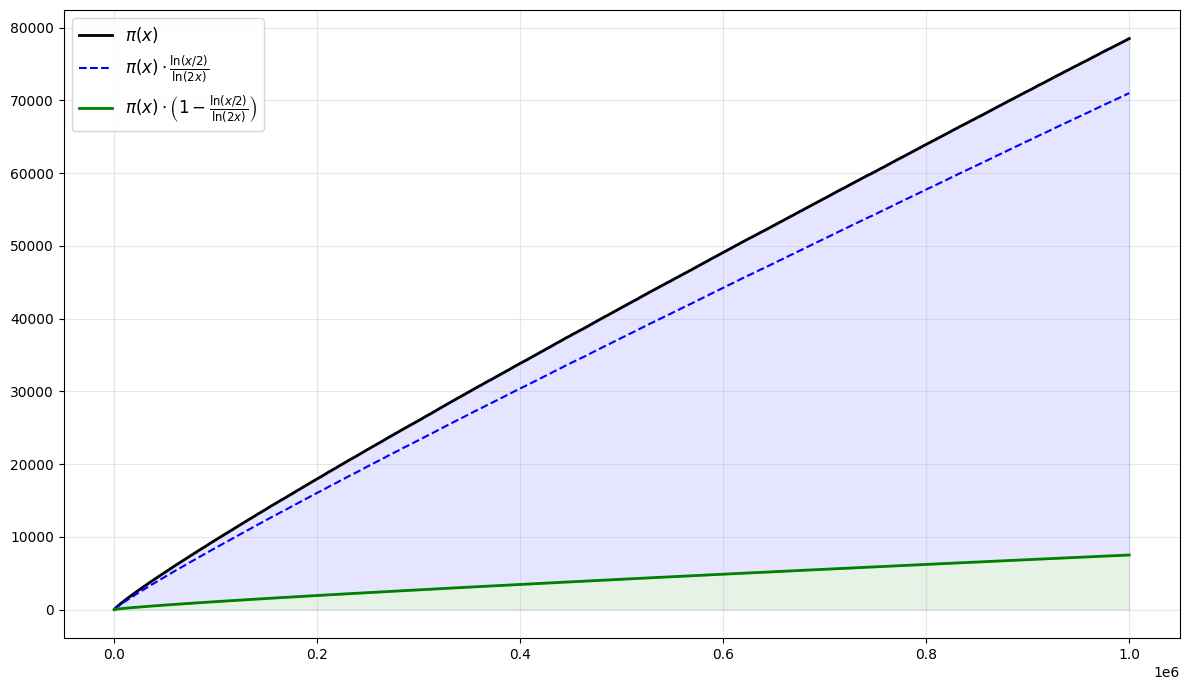

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decomposition(limit):
    print(f"Generando primos hasta {limit}...")

    # 1. Criba de Eratóstenes para obtener pi(x) EXACTO
    is_prime = np.ones(limit + 1, dtype=bool)
    is_prime[0:2] = False
    for i in range(2, int(np.sqrt(limit)) + 1):
        if is_prime[i]:
            is_prime[i*i::i] = False

    # Suma acumulada para obtener la función escalonada pi(x)
    pi_x_exact = np.cumsum(is_prime)

    # Preparamos el eje X (desde 3 para evitar problemas con logaritmos)
    x = np.arange(3, limit + 1)
    y_pi = pi_x_exact[3:]

    # 2. Calcular el Factor de "Atenuación"
    # factor = ln(x/2) / ln(2x)
    factor = np.log(x / 2.0) / np.log(2.0 * x)

    # 3. Calcular las dos funciones
    y_major = y_pi * factor          # La primera que probamos
    y_minor = y_pi * (1 - factor)    # La segunda (el "residuo")

    # -------- GRAFICAR .------
    plt.figure(figsize=(12, 7))

    # 1. pi(x) Real (La Totalidad)
    plt.plot(x, y_pi, color='black', linewidth=2,
             label=r'$\pi(x)$')

    # 2. La Parte Mayor (Primera fórmula)
    plt.plot(x, y_major, color='blue', linestyle='--', linewidth=1.5,
             label=r'$\pi(x) \cdot \frac{\ln(x/2)}{\ln(2x)}$')

    # 3. La Parte Menor (Segunda fórmula)%%
    plt.plot(x, y_minor, color='green', linestyle='-', linewidth=2,
             label=r'$\pi(x) \cdot \left(1 - \frac{\ln(x/2)}{\ln(2x)}\right)$')

    # Rellenar el área para mostrar que suman el total
    plt.fill_between(x, 0, y_minor, color='green', alpha=0.1)
    plt.fill_between(x, y_minor, y_minor + y_major, color='blue', alpha=0.1)

    # Configuración de etiquetas (vaciadas según tu código original)
    plt.title(f'')
    plt.xlabel('')
    plt.ylabel('')
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, alpha=0.3)

    # Mostrar valores finales para comparación numérica en consola%
    print(f"--- Valores finales en x={limit} ---")
    print(f"Total pi(x):   {y_pi[-1]}")
    print(f"Parte Mayor:   {y_major[-1]:.2f}")
    print(f"Parte Menor:   {y_minor[-1]:.2f}")
    print(f"Suma (M+m):    {y_major[-1] + y_minor[-1]:.2f}")

    plt.tight_layout()

    # --- GUARDAR EN PDF (Líneas añadidas) ---
    # Guarda como___ p9.pdf. bbox_inches='tight'
    plt.savefig("p9.pdf", format='pdf', bbox_inches='tight', dpi=300)
    print("\nArchivo guardado exitosamente como: p9.pdf")

    # Mostrar el gráfico en pantalla
    plt.show()

if __name__ == "__main__":
    # Ejecutamos la función
    plot_decomposition(1000000)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from sympy import sieve
import numpy as np
import time
import os


# 1. CONFIGURACIÓN GENERA
lista_N = [500, 5000, 50000, 500000, 5000000, 50000000]
mapa_color_base = 'hot'
output_dir = "goldbach_evolucion_transparente"

# Crear directorio para guardar los archivos
os.makedirs(output_dir, exist_ok=True)


# 2. FUNCIÓN DE CONFIGURACIÓN ADAPTATIVA

def obtener_config(n):
    """
    Define la resolución y el filtro de corte según el tamaño de N.
    Esto es necesario porque un filtro del 40% que funciona bien para 50M,
    borraría todos los puntos para N=500.
    """
    if n <= 1000:
        # N muy pequeño: Resolución baja para puntos grandes, SIN FILTRO.
        return {'width': 1000, 'height': 800, 'corte_pct': 0.0, 'intensidad_vis': 100}
    elif n <= 50000:
        # N medio-bajo: Resolución media, filtro muy suave.
        return {'width': 2000, 'height': 1500, 'corte_pct': 0.10, 'intensidad_vis': 99.8}
    elif n <= 5000000:
        # N medio-alto: Alta resolución, filtro moderado (tu código 1)
        return {'width': 4000, 'height': 3000, 'corte_pct': 0.35, 'intensidad_vis': 99.9}
    else:
        # N gigante: Máxima resolución, filtro agresivo (tu código 2)
        # Nota: Bajé un poco la res máxima (6000x4500) para evitar crashes en Colab gratuito.
        return {'width': 6000, 'height': 4500, 'corte_pct': 0.41, 'intensidad_vis': 99.9}

# ==========================================
# 3. MOTOR GENERADOR (ORIGINAL)
# ==========================================
def generar_frame_original_style(max_natural):
    cfg = obtener_config(max_natural)
    print(f"\n--- PROCESANDO N = {max_natural:,} ---")
    print(f"Config: Res={cfg['width']}x{cfg['height']}, Corte={cfg['corte_pct']:.0%}")
    start_time = time.time()

    # A. Generar Primos
    limit_calc = max_natural * 2
    try:
        sieve.extend_to_no(limit_calc)
    except:
        sieve.extend(limit_calc)

    todos_los_primos = np.array(sieve._list, dtype=np.int64)
    todos_los_primos = todos_los_primos[todos_los_primos <= limit_calc]

    corte_primos = np.searchsorted(todos_los_primos, max_natural, side='right')
    primos_filas = todos_los_primos[:corte_primos]
    max_y_limit = len(primos_filas)

    # Ejes
    x_vals = np.linspace(2, max_natural, cfg['width'])
    pi_vals = np.searchsorted(todos_los_primos, x_vals, side='right')
    pi2_vals = np.searchsorted(todos_los_primos, 2 * x_vals, side='right')

    #  B. Rasteriza
    density_matrix = np.zeros((cfg['height'], cfg['width']), dtype=np.float32)
    col_indices = np.arange(cfg['width'])
    # Chunk dinámico: más grande para N más grandes para acelerar
    chunk_size = 25000 if max_natural > 1000000 else 5000

    print("Calculando matriz...")
    for i in range(0, len(primos_filas), chunk_size):
        chunk = primos_filas[i : i + chunk_size]
        Y_chunk = pi2_vals[None, :] - chunk[:, None]

        # Mapeo
        pixel_y = ((Y_chunk / max_y_limit) * cfg['height']).astype(np.int32)

        # Filtros
        mask_invalid = (Y_chunk < pi_vals[None, :]) | (pixel_y >= cfg['height']) | (pixel_y < 0)
        pixel_y[mask_invalid] = -1

        # Llenado vectorizado optimizado
        for row_idx in range(len(chunk)):
            row = pixel_y[row_idx]
            valid = row >= 0
            if np.any(valid):
                ys = cfg['height'] - 1 - row[valid]
                xs = col_indices[valid]
                density_matrix[ys, xs] += 1

    # --- C. Filtrado Dinámico (Estilo Original) ---
    matrix_to_render = density_matrix.copy()
    max_intersecciones = np.nanmax(matrix_to_render)

    if cfg['corte_pct'] > 0 and max_intersecciones > 0:
        umbral_dinamico = max_intersecciones * cfg['corte_pct']
        # Volvemos transparentes los puntos de baja intensidad
        mask_low_intensity = matrix_to_render < umbral_dinamico
        matrix_to_render[mask_low_intensity] = np.nan

    puntos_visibles = np.sum(~np.isnan(matrix_to_render))
    print(f"Puntos visibles: {puntos_visibles:,}")

    # --- D. Colormap Transparente (TU CÓDIGO ORIGINAL) ---
    cmap_original = plt.get_cmap(mapa_color_base)
    n_colors = 256
    colores_con_alfa = cmap_original(np.linspace(0, 1, n_colors))
    for i in range(n_colors):
        # Tu ajuste de alfa lineal original
        colores_con_alfa[i, 3] = 0.5 + 0.5 * (i / (n_colors - 1))

    cmap_transparente = LinearSegmentedColormap.from_list(
        f"Transparent_{mapa_color_base}", colores_con_alfa, N=n_colors
    )

    # --- E. Renderizado -
    fig, ax = plt.subplots(figsize=(12, 9))

    # FONDO TRANSPARENTE
    fig.patch.set_alpha(0.0)
    ax.set_facecolor((0,0,0,0))

    if puntos_visibles > 0:
        datos_validos = matrix_to_render[~np.isnan(matrix_to_render)]
        vmin_val = np.nanmin(datos_validos)
        if cfg['intensidad_vis'] >= 100:
             vmax_val = np.nanmax(datos_validos)
        else:
             vmax_val = np.percentile(datos_validos, cfg['intensidad_vis'])
    else:
        vmin_val, vmax_val = 0, 1

    ax.imshow(matrix_to_render,
              extent=[2, max_natural, 0, max_y_limit],
              aspect='auto',
              cmap=cmap_transparente,
              interpolation='nearest',
              origin='upper',
              norm=Normalize(vmin=vmin_val, vmax=vmax_val))

    # Estilo de ejes (Gris original)
    ax.set_xlim(2, max_natural)
    ax.set_ylim(0, max_y_limit)
    ax.set_title(f"N = {max_natural:,}", color='gray', fontsize=14)
    ax.set_xlabel('n', color='gray')
    ax.set_ylabel('p', color='gray')
    ax.tick_params(colors='gray')
    for spine in ax.spines.values(): spine.set_edgecolor('gray')

    # Guardar PNG transparente
    filename = f"{output_dir}/goldbach_N_{max_natural}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight', transparent=True)

    print(f"Guardado en: {filename} ({time.time() - start_time:.1f}s)")


    plt.show()
    plt.close(fig)

# ==========================================
# 4. EJECUCIÓN DEL BUCLE
# ==========================================
print(f"Iniciando generación de {len(lista_N)} imágenes...")
for n in lista_N:
    generar_frame_original_style(n)

print(f"\n--- PROCESO COMPLETO ---")
print(f"Las imágenes están en la carpeta: {output_dir}")


--- PROCESANDO N = 500 ---
 -> Calculando matriz...
 -> Renderizando con fondo negro...
 -> Guardado: goldbach_fondo_negro/goldbach_black_500.png (0.8s)


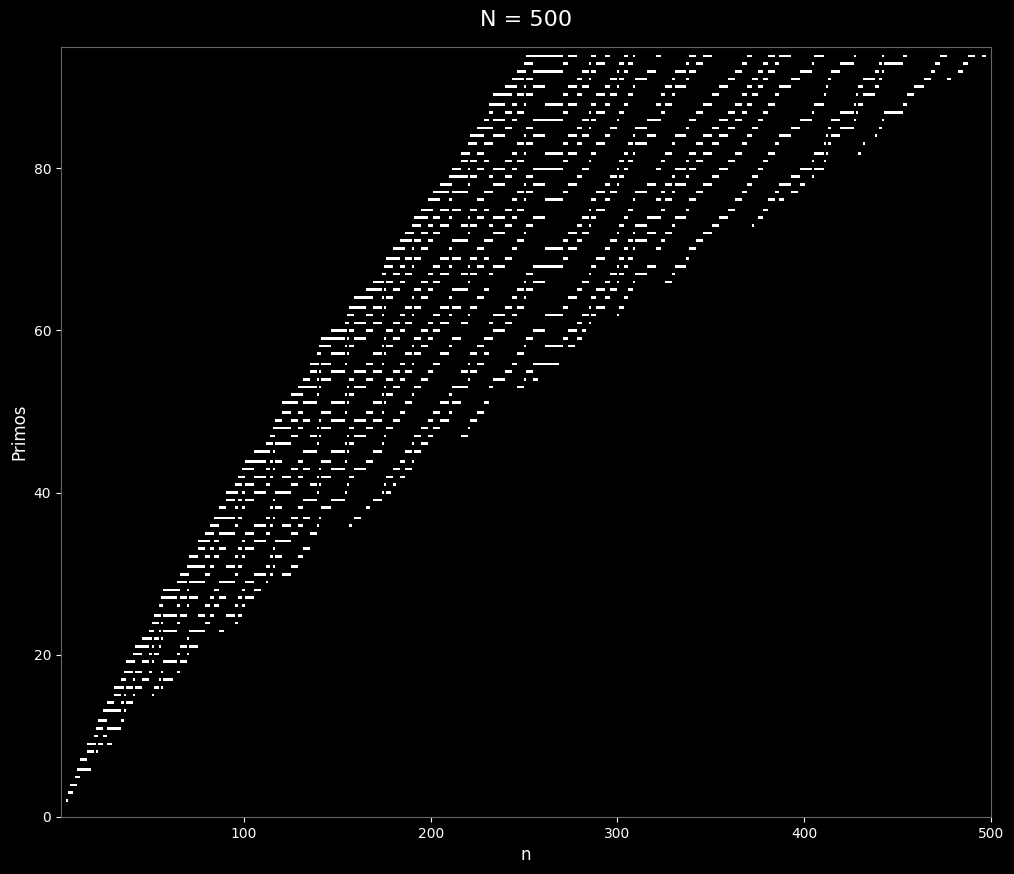


--- PROCESANDO N = 5,000 ---
 -> Calculando matriz...
 -> Renderizando con fondo negro...
 -> Guardado: goldbach_fondo_negro/goldbach_black_5000.png (1.1s)


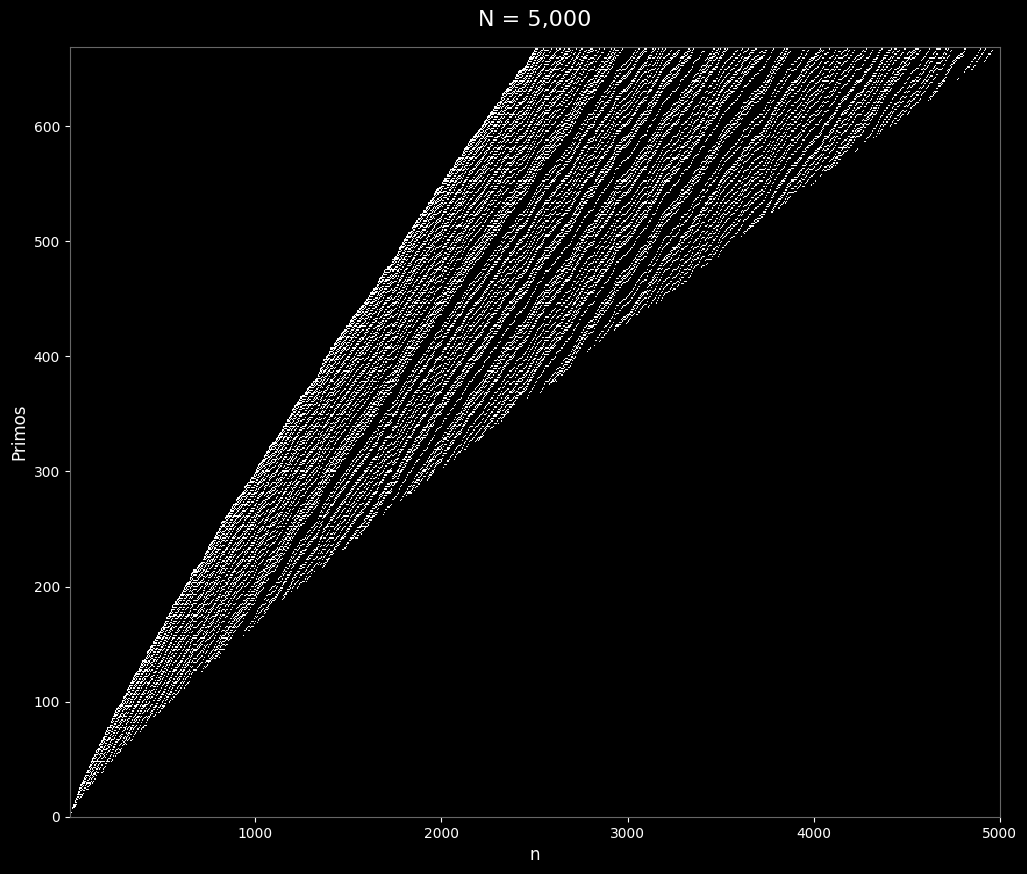


--- PROCESANDO N = 50,000 ---
 -> Calculando matriz...
 -> Renderizando con fondo negro...
 -> Guardado: goldbach_fondo_negro/goldbach_black_50000.png (1.2s)


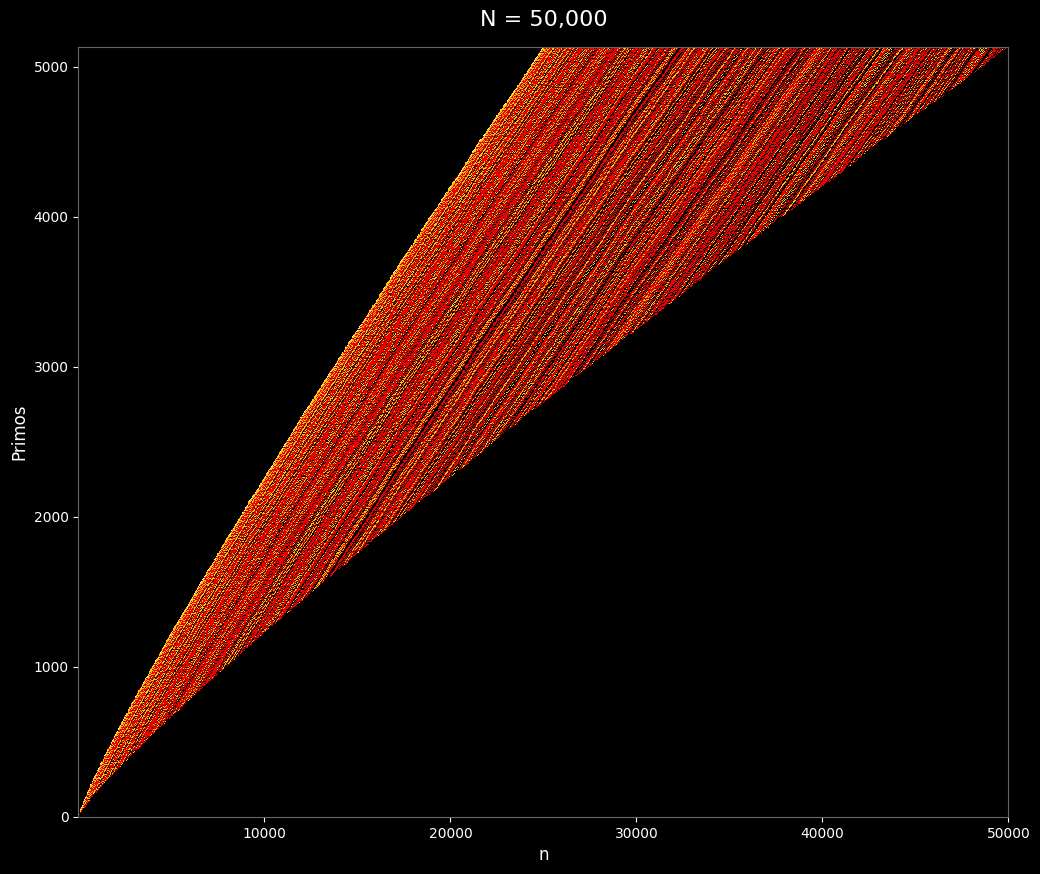


--- PROCESANDO N = 500,000 ---
 -> Calculando matriz...
 -> Renderizando con fondo negro...
 -> Guardado: goldbach_fondo_negro/goldbach_black_500000.png (3.7s)


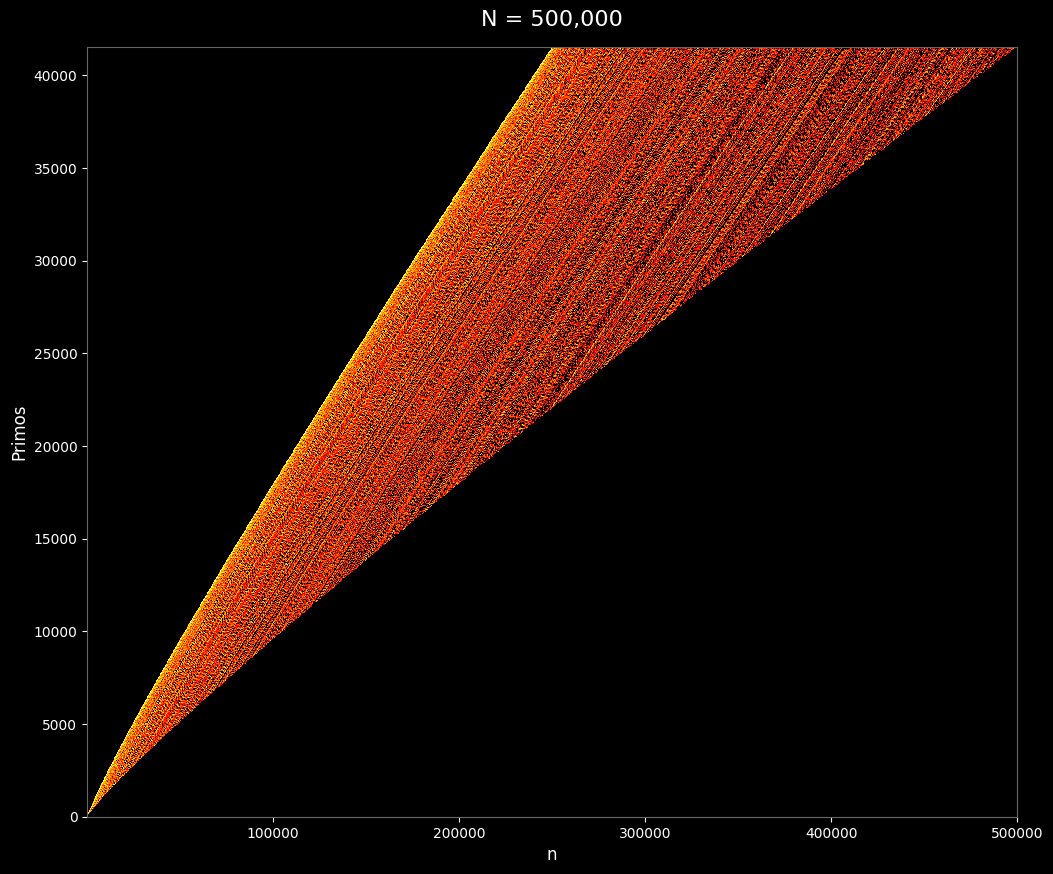


--- PROCESANDO N = 5,000,000 ---
 -> Calculando matriz...
    Progreso: 0%
 -> Renderizando con fondo negro...
 -> Guardado: goldbach_fondo_negro/goldbach_black_5000000.png (84.1s)


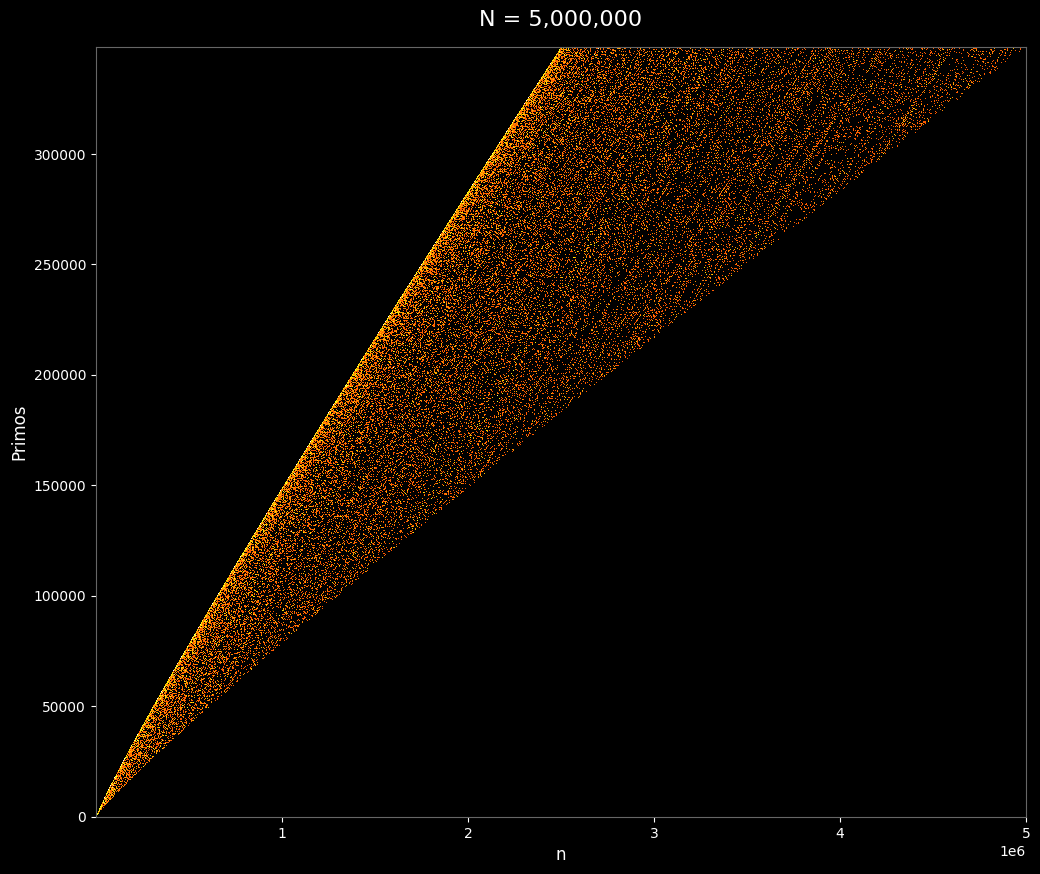


--- PROCESANDO N = 50,000,000 ---
 -> Calculando matriz...
    Progreso: 0%


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sympy import sieve
import numpy as np
import time
import os

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
output_dir = "goldbach_fondo_negro"
os.makedirs(output_dir, exist_ok=True)

# Diccionario Adaptativo:
# - Para N pequeños: Baja resolución + Sin filtro (Crea efecto sólido)
# - Para N grandes: Alta resolución + Tu filtro estricto (Muestra detalle fino)
CONFIGURACIONES = {
    500:      {'width': 400,   'height': 300,   'corte': 0.0,  'gamma': 100},
    5000:     {'width': 800,   'height': 600,   'corte': 0.0,  'gamma': 99.8},
    50000:    {'width': 1200,  'height': 900,   'corte': 0.05, 'gamma': 99.8},
    500000:   {'width': 2000,  'height': 1500,  'corte': 0.25, 'gamma': 99.9},
    5000000:  {'width': 8000,  'height': 6000,  'corte': 0.41, 'gamma': 99.9}, # Tu Config 1
    50000000: {'width': 10000, 'height': 8000,  'corte': 0.43, 'gamma': 99.4}  # Tu Config 2
}

lista_N = [500, 5000, 50000, 500000, 5000000, 50000000]

# ==========================================
# 2. MOTOR DE GENERACIÓN
# ==========================================
def generar_goldbach_solido(max_natural):
    cfg = CONFIGURACIONES[max_natural]
    print(f"\n--- PROCESANDO N = {max_natural:,} ---")
    start_time = time.time()

    # A. PRIMOS
    limit_calc = max_natural * 2
    try: sieve.extend(limit_calc)
    except: pass

    todos_los_primos = np.array(sieve._list, dtype=np.int64)
    todos_los_primos = todos_los_primos[todos_los_primos <= limit_calc]

    corte_idx = np.searchsorted(todos_los_primos, max_natural, side='right')
    primos_filas = todos_los_primos[:corte_idx]
    max_y = len(primos_filas)

    # Ejes
    x_vals = np.linspace(2, max_natural, cfg['width'])
    pi_vals = np.searchsorted(todos_los_primos, x_vals, side='right')
    pi2_vals = np.searchsorted(todos_los_primos, 2 * x_vals, side='right')

    # B. RASTERIZACIÓN
    print(" -> Calculando matriz...")
    density = np.zeros((cfg['height'], cfg['width']), dtype=np.float32)
    col_indices = np.arange(cfg['width'])
    chunk_size = 50000 if max_natural > 1000000 else 5000

    for i in range(0, len(primos_filas), chunk_size):
        chunk = primos_filas[i : i + chunk_size]
        Y_chunk = pi2_vals[None, :] - chunk[:, None]

        pixel_y = ((Y_chunk / max_y) * cfg['height']).astype(np.int32)

        mask_invalid = (Y_chunk < pi_vals[None, :]) | (pixel_y >= cfg['height']) | (pixel_y < 0)
        pixel_y[mask_invalid] = -1

        for r in range(len(chunk)):
            row = pixel_y[r]
            valid = row >= 0
            if np.any(valid):
                density[cfg['height'] - 1 - row[valid], col_indices[valid]] += 1

        if max_natural >= 5000000 and i % (chunk_size*10) == 0:
            print(f"    Progreso: {i/len(primos_filas):.0%}")

    # C. FILTRADO Y FONDO
    print(" -> Renderizando con fondo negro...")

    # 1. Aplicar corte de intensidad (para limpiar ruido en N grandes)
    if cfg['corte'] > 0:
        umbral = np.nanmax(density) * cfg['corte']
        density[density < umbral] = np.nan
    else:
        # Para N pequeños, solo ocultamos donde no hay nada (0)
        density[density == 0] = np.nan

    # 2. Configurar Colormap para FONDO NEGRO
    cmap = plt.get_cmap('hot').copy()
    cmap.set_bad('black') # <---

    # 3. Normalización visual
    valid_data = density[~np.isnan(density)]
    if len(valid_data) > 0:
        vmax = np.percentile(valid_data, cfg['gamma']) if cfg['gamma'] < 100 else np.max(valid_data)
    else:
        vmax = 1

    # D. PLOT FINAL
    fig, ax = plt.subplots(figsize=(12, 10))

    # --FONDO ---
    fig.patch.set_facecolor('black')  # Fondo de la imagen global
    ax.set_facecolor('black')         # Fondo de los ejes

    ax.imshow(density,
              extent=[2, max_natural, 0, max_y],
              aspect='auto',
              cmap=cmap,
              interpolation='nearest',
              origin='upper',
              norm=Normalize(vmin=0, vmax=vmax))

    # E. ESTÉTICA BEAMER (Texto Blanco)
    ax.set_title(f"N = {max_natural:,}", color='white', fontsize=16, pad=15)
    ax.set_xlabel('n', color='white', fontsize=12)
    ax.set_ylabel('Primos', color='white', fontsize=12)

    ax.tick_params(axis='both', colors='white', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#666666') # Borde gris suave

    # Guardar con facecolor negro
    filename = f"{output_dir}/goldbach_black_{max_natural}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='black')

    print(f" -> Guardado: {filename} ({time.time() - start_time:.1f}s)")
    plt.show()
    plt.close(fig)

# ==========================================
# EJECUCIÓN
# ==========================================
for n in lista_N:
    generar_goldbach_solido(n)

In [8]:
import mpmath
import os

def analizar_archivo_oeis_corregido():
    archivo_txt = "b001359.txt"

    print("="*110)
    print("  ANÁLISIS DE 1000 PUNTOS - PRIMOS GEMELOS (GAP 2) BASADO EN OEIS A001359")
    print("  TU MODELO GEOMÉTRICO: Predicción = Li(x) * [1 - ln(x/2)/ln(2x)] * k")
    print("="*110)

    # Verificar si el archivo existe
    if not os.path.exists(archivo_txt):
        print(f"ERROR: No se encontró el archivo '{archivo_txt}' en esta carpeta.")
        return

    # Precisión alta
    mpmath.mp.dps = 50
    k = mpmath.mpf('1.0')  # Constante para Gap 2 (Primos Gemelos)

    puntos_evaluados = 0

    print(f"{'LÍMITE (X)':<15} | {'CONTEO REAL':<15} | {'TU MODELO':<15} | {'DIFERENCIA':<15} | {'ERROR %':<10}")
    print("-" * 110)

    with open(archivo_txt, "r") as f:
        for linea in f:
            # Ignorar líneas vacías o comentarios
            if not linea.strip() or linea.startswith("#"):
                continue

            partes = linea.split()
            if len(partes) == 2:
                n_conteo = int(partes[0])
                x_val = int(partes[1])

                # Tomamos 1 de cada 100 datos para tener 1000 puntos
                if n_conteo % 100 == 0:

                    x_mp = mpmath.mpf(x_val)

                    # 1. MOTOR AUTÓNOMO
                    pi_x_estimado = mpmath.li(x_mp)

                    # 2. EL TÉRMINO GEOMÉTRICO DE TU PAPER
                    ln_x_half = mpmath.log(x_mp / 2.0)
                    ln_2x     = mpmath.log(2.0 * x_mp)
                    termino_geo = mpmath.mpf('1.0') - (ln_x_half / ln_2x)

                    # 3. MI FÓRMULA EXACTA
                    prediccion = pi_x_estimado * termino_geo * k

                    # Cálculo de errores
                    diferencia = prediccion - n_conteo
                    error_pct = (diferencia / n_conteo) * 100

                    signo = "+" if error_pct > 0 else ""

                    print(f"{x_val:<15,d} | {n_conteo:<15,d} | {int(prediccion):<15,d} | {int(diferencia):<+15,d} | {signo}{float(error_pct):.4f}%")
                    puntos_evaluados += 1

    print("-" * 110)
    print(f"¡Análisis completado! Se compararon {puntos_evaluados} puntos usando tu término geométrico.")
    print("="*110)

if __name__ == "__main__":
    analizar_archivo_oeis_corregido()

  ANÁLISIS DE 1000 PUNTOS - PRIMOS GEMELOS (GAP 2) BASADO EN OEIS A001359
  TU MODELO GEOMÉTRICO: Predicción = Li(x) * [1 - ln(x/2)/ln(2x)] * k
ERROR: No se encontró el archivo 'b001359.txt' en esta carpeta.


In [7]:
import mpmath
import sympy
import os

def analizar_archivo_con_pi_real():
    archivo_txt = "b001359.txt"

    print("="*110)
    print("  ANÁLISIS DE PUNTOS - AISLANDO LA HEURÍSTICA GEOMÉTRICA")
    print("  TU MODELO: Predicción = pi(x)_real * [1 - ln(x/2)/ln(2x)] * k")
    print("="*110)

    if not os.path.exists(archivo_txt):
        print(f"ERROR: No se encontró el archivo '{archivo_txt}'.")
        return

    mpmath.mp.dps = 50
    k = mpmath.mpf('1.0')

    puntos_evaluados = 0

    print(f"{'LÍMITE (X)':<12} | {'CONTEO REAL':<12} | {'pi(x) REAL':<12} | {'Mi MODELO':<12} | {'DIFERENCIA':<12} | {'ERROR %':<10}")
    print("-" * 110)

    with open(archivo_txt, "r") as f:
        for linea in f:
            if not linea.strip() or linea.startswith("#"):
                continue

            partes = linea.split()
            if len(partes) == 2:
                n_conteo = int(partes[0])
                x_val = int(partes[1])

                # Tomamos 1 de cada 100 datos para que no tarde demasiado
                if n_conteo % 100 == 0:

                    # 1. pi(x) EXACTO convertido a int nativo de Python
                    pi_x_real = int(sympy.primepi(x_val))
                    pi_x_mp = mpmath.mpf(pi_x_real)

                    # 2. EL TÉRMINO GEOMÉTRICO
                    x_mp = mpmath.mpf(x_val)
                    ln_x_half = mpmath.log(x_mp / 2.0)
                    ln_2x     = mpmath.log(2.0 * x_mp)
                    termino_geo = mpmath.mpf('1.0') - (ln_x_half / ln_2x)

                    # 3. PREDICCIÓN PURA
                    prediccion = pi_x_mp * termino_geo * k

                    diferencia = prediccion - n_conteo
                    error_pct = (diferencia / n_conteo) * 100

                    signo = "+" if error_pct > 0 else ""

                    print(f"{x_val:<12,d} | {n_conteo:<12,d} | {pi_x_real:<12,d} | {int(prediccion):<12,d} | {int(diferencia):<+12,d} | {signo}{float(error_pct):.4f}%")
                    puntos_evaluados += 1

    print("-" * 110)
    print(f"¡Análisis completado! Se aislaron {puntos_evaluados} puntos usando pi(x) real.")
    print("="*110)

if __name__ == "__main__":
    analizar_archivo_con_pi_real()

  ANÁLISIS DE PUNTOS - AISLANDO LA HEURÍSTICA GEOMÉTRICA
  TU MODELO: Predicción = pi(x)_real * [1 - ln(x/2)/ln(2x)] * k
ERROR: No se encontró el archivo 'b001359.txt'.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import mpmath
import sympy
import os
import urllib.request

def descargar_archivo_oeis(numero_secuencia):
    """
    Descarga automáticamente el archivo de texto (b-file) desde la OEIS.
    """
    nombre_archivo = f"b{numero_secuencia}.txt"
    url = f"https://oeis.org/A{numero_secuencia}/{nombre_archivo}"

    if os.path.exists(nombre_archivo):
        return nombre_archivo

    print(f"-> Descargando {nombre_archivo} desde {url} ...")
    try:
        urllib.request.urlretrieve(url, nombre_archivo)
        print(f"-> ¡Descarga completada!\n")
        return nombre_archivo
    except Exception as e:
        print(f"-> Error al descargar {nombre_archivo}. Detalles: {e}\n")
        return None

def calcular_constante_k(gap):
    """
    Calcula la constante k de ajuste basada en los factores primos del gap.
    Aplicable para familias de k-tuplas primas.
    Para gap=2, k=1. Para gap=6, k=2, etc.
    """
    k = 1.0
    factores_primos = sympy.primefactors(gap)
    for p in factores_primos:
        if p > 2:
            k *= (p - 1) / (p - 2)
    return mpmath.mpf(str(k))

def analizar_archivo_gap(archivo_txt, gap):
    """
    Analiza la convergencia de la heurística propuesta frente a datos reales de la OEIS.
    Aísla el comportamiento geométrico utilizando el valor real de pi(x).
    """
    if not archivo_txt or not os.path.exists(archivo_txt):
        print(f"Error: No se encontró el archivo para procesar el gap {gap}.")
        return

    # Configuración de precisión arbitraria para evitar artefactos de punto flotante
    mpmath.mp.dps = 50

    # AQUÍ SE CALCULA k AUTOMÁTICAMENTE SEGÚN EL GAP
    k = calcular_constante_k(gap)

    print("="*115)
    print(f"  ANÁLISIS ASINTÓTICO - PRIMOS CON GAP {gap}")
    print(f"  Archivo de datos: {archivo_txt}")
    print("  MODELO: Predicción = pi(x)_real * [1 - ln(x/2)/ln(2x)] * k")
    print(f"  Constante k calculada para gap {gap}: {k}")
    print("="*115)
    print(f"{'X (LÍMITE)':<12} | {'CONTEO REAL':<12} | {'pi(x) REAL':<12} | {'PREDICCIÓN':<12} | {'DIFERENCIA':<12} | {'ERROR %':<10}")
    print("-" * 115)

    puntos_evaluados = 0

    with open(archivo_txt, "r") as f:
        for linea in f:
            if not linea.strip() or linea.startswith("#"):
                continue

            partes = linea.split()
            if len(partes) == 2:
                n_conteo = int(partes[0])
                x_val = int(partes[1])

                # Muestreo estratificado: 1 de cada 100 puntos de control
                if n_conteo % 100 == 0:

                    # 1. Función contadora de primos exacta
                    pi_x_real = int(sympy.primepi(x_val))
                    pi_x_mp = mpmath.mpf(pi_x_real)

                    # 2. Heurística geométrica propuesta
                    x_mp = mpmath.mpf(x_val)
                    ln_x_half = mpmath.log(x_mp / 2.0)
                    ln_2x     = mpmath.log(2.0 * x_mp)
                    termino_geo = mpmath.mpf('1.0') - (ln_x_half / ln_2x)

                    # 3. Cálculo de la predicción final (incluye la constante k calculada)
                    prediccion = pi_x_mp * termino_geo * k

                    diferencia = prediccion - n_conteo
                    error_pct = (diferencia / n_conteo) * 100

                    signo = "+" if error_pct > 0 else ""

                    print(f"{x_val:<12,d} | {n_conteo:<12,d} | {pi_x_real:<12,d} | {int(prediccion):<12,d} | {int(diferencia):<+12,d} | {signo}{float(error_pct):.4f}%")
                    puntos_evaluados += 1

    print("-" * 115)
    print(f"Análisis completado. Se procesaron {puntos_evaluados} puntos de control.")
    print("="*115)
    print("\n")

if __name__ == "__main__":
    # Diccionario con los gaps a analizar y sus respectivas secuencias en la OEIS
    secuencias_oeis = {
        2: "001359",  # Gemelos
        4: "023200",  # Primos
        6: "023201",  # Sexis
        8: "023202",
        10: "023203",
        12: "023204",
        14: "023205"
    }

    # Procesa cada gap automáticamente
    for gap_actual, num_secuencia in secuencias_oeis.items():
        print(f"Iniciando procesamiento para Gap {gap_actual}...")
        archivo_local = descargar_archivo_oeis(num_secuencia)
        analizar_archivo_gap(archivo_local, gap=gap_actual)

Iniciando procesamiento para Gap 2...
-> Descargando b001359.txt desde https://oeis.org/A001359/b001359.txt ...
-> Error al descargar b001359.txt. Detalles: HTTP Error 403: Forbidden

Error: No se encontró el archivo para procesar el gap 2.
Iniciando procesamiento para Gap 4...
-> Descargando b023200.txt desde https://oeis.org/A023200/b023200.txt ...
-> Error al descargar b023200.txt. Detalles: HTTP Error 403: Forbidden

Error: No se encontró el archivo para procesar el gap 4.
Iniciando procesamiento para Gap 6...
-> Descargando b023201.txt desde https://oeis.org/A023201/b023201.txt ...
-> Error al descargar b023201.txt. Detalles: HTTP Error 403: Forbidden

Error: No se encontró el archivo para procesar el gap 6.
Iniciando procesamiento para Gap 8...
-> Descargando b023202.txt desde https://oeis.org/A023202/b023202.txt ...
-> Error al descargar b023202.txt. Detalles: HTTP Error 403: Forbidden

Error: No se encontró el archivo para procesar el gap 8.
Iniciando procesamiento para Gap 10.

In [5]:
import mpmath
import sympy
import os
import urllib.request

# =====================================================
# CARPETA EN GOOGLE DRIVE DONDE SE GUARDARÁN LOS ARCHIVOS
# =====================================================

CARPETA_DRIVE = "/content/drive/MyDrive/secuencias"
os.makedirs(CARPETA_DRIVE, exist_ok=True)


# =====================================================
# DESCARGAR ARCHIVO DESDE OEIS
# =====================================================

def descargar_archivo_oeis(numero_secuencia):

    nombre_archivo = f"{CARPETA_DRIVE}/b{numero_secuencia}.txt"
    url = f"https://oeis.org/A{numero_secuencia}/b{numero_secuencia}.txt"

    if os.path.exists(nombre_archivo):
        print(f"Archivo ya existe: {nombre_archivo}")
        return nombre_archivo

    print(f"Descargando {url}")

    try:
        urllib.request.urlretrieve(url, nombre_archivo)
        print(f"Descarga completada: {nombre_archivo}\n")
        return nombre_archivo
    except Exception as e:
        print(f"Error descargando archivo: {e}")
        return None


# CALCULAR CONSTANTE k SEGÚN FACTORES PRIMOS
# ==============================

def calcular_constante_k(gap):

    k = 1.0
    factores_primos = sympy.primefactors(gap)

    for p in factores_primos:
        if p > 2:
            k *= (p - 1) / (p - 2)

    return mpmath.mpf(str(k))


# ANALIZAR ARCHIVO
# ====================

def analizar_archivo_gap(archivo_txt, gap):

    if not archivo_txt or not os.path.exists(archivo_txt):
        print(f"Error: no se encontró archivo para gap {gap}")
        return

    mpmath.mp.dps = 50
    k = calcular_constante_k(gap)

    datos_validos = []

    with open(archivo_txt, "r") as f:
        for linea in f:

            if not linea.strip() or linea.startswith("#"):
                continue

            partes = linea.split()

            if len(partes) == 2:
                datos_validos.append((int(partes[0]), int(partes[1])))

    total_datos = len(datos_validos)

    if total_datos == 0:
        print("Archivo sin datos")
        return

    # muestreo dinámico
    if total_datos <= 20:
        paso = 1
    elif total_datos <= 100:
        paso = 10
    elif total_datos <= 1000:
        paso = 100
    else:
        paso = total_datos // 15

    print("="*115)
    print(f"ANÁLISIS ASINTÓTICO - GAP {gap}")
    print(f"Archivo: {archivo_txt}")
    print(f"Datos disponibles: {total_datos}")
    print(f"Constante k: {k}")
    print("="*115)

    print(f"{'X':<12} | {'REAL':<12} | {'pi(x)':<12} | {'MODELO':<12} | {'DIF':<12} | {'ERROR %':<10}")
    print("-"*115)

    puntos = 0

    for n_conteo, x_val in datos_validos:

        if n_conteo % paso == 0 or n_conteo == total_datos:

            pi_x = int(sympy.primepi(x_val))

            pi_mp = mpmath.mpf(pi_x)
            x_mp = mpmath.mpf(x_val)

            termino = 1 - (mpmath.log(x_mp/2) / mpmath.log(2*x_mp))

            prediccion = pi_mp * termino * k

            diferencia = prediccion - n_conteo
            error = (diferencia / n_conteo) * 100

            signo = "+" if error > 0 else ""

            print(f"{x_val:<12,d} | {n_conteo:<12,d} | {pi_x:<12,d} | {int(prediccion):<12,d} | {int(diferencia):<+12,d} | {signo}{float(error):.4f}%")

            puntos += 1

    print("-"*115)
    print(f"Puntos analizados: {puntos}")
    print("="*115)
    print()


# PROGRAMA PRINCIPAL
# =============================

secuencias_oeis = {

    2: "001359",
    4: "023200",
    6: "023201",
    8: "023202",
    10: "023203",
    12: "023204",
    14: "023205"

}

for gap, secuencia in secuencias_oeis.items():

    archivo = descargar_archivo_oeis(secuencia)

    analizar_archivo_gap(archivo, gap)

Descargando https://oeis.org/A001359/b001359.txt
Error descargando archivo: HTTP Error 403: Forbidden
Error: no se encontró archivo para gap 2
Descargando https://oeis.org/A023200/b023200.txt
Error descargando archivo: HTTP Error 403: Forbidden
Error: no se encontró archivo para gap 4
Descargando https://oeis.org/A023201/b023201.txt
Error descargando archivo: HTTP Error 403: Forbidden
Error: no se encontró archivo para gap 6
Descargando https://oeis.org/A023202/b023202.txt
Error descargando archivo: HTTP Error 403: Forbidden
Error: no se encontró archivo para gap 8
Descargando https://oeis.org/A023203/b023203.txt
Error descargando archivo: HTTP Error 403: Forbidden
Error: no se encontró archivo para gap 10
Descargando https://oeis.org/A023204/b023204.txt
Error descargando archivo: HTTP Error 403: Forbidden
Error: no se encontró archivo para gap 12
Descargando https://oeis.org/A023205/b023205.txt
Error descargando archivo: HTTP Error 403: Forbidden
Error: no se encontró archivo para gap

--- INICIANDO PROCESO PARA N = 50,000,000 | GAP = 6 ---
1. Cargando todos los primos...
2. Filtrando primos que inician un Gap de 6...
   -> Se encontraron 414,308 primos con Gap 6 en este rango.
3. Calculando matriz de densidad...
4. Aplicando filtro dinámico...
   -> Puntos visibles restantes: 9,682,441
5. Renderizando imagen final...
--- LISTO. Imagen guardada como: grafico_gap_6_N_50000000.pdf ---
Tiempo total: 2.56 minutos


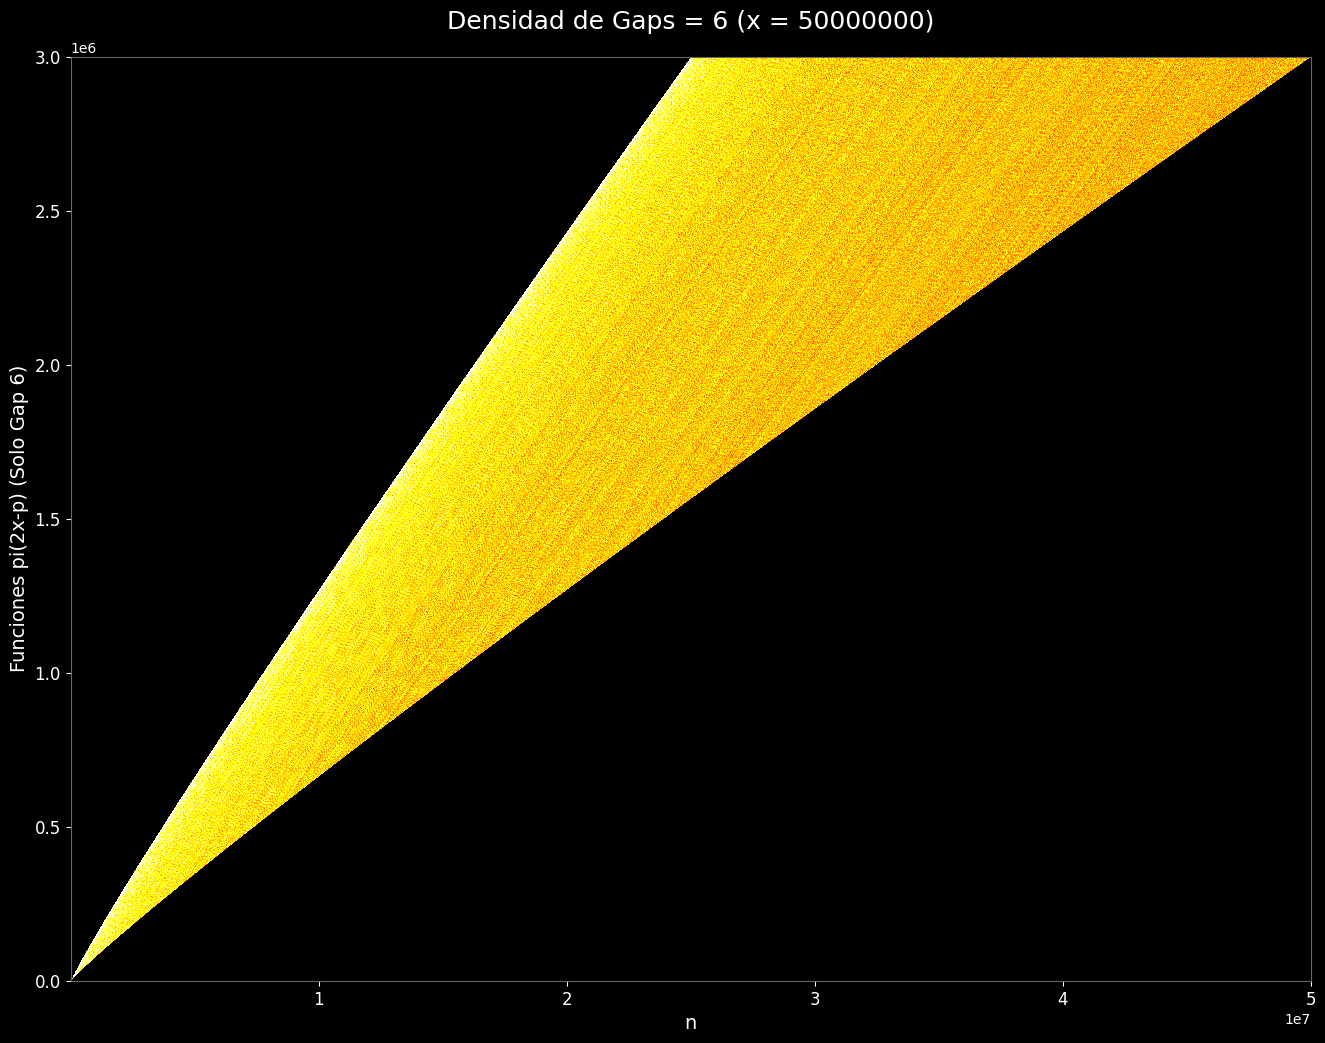

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from sympy import sieve
import numpy as np
import time


# 1. PANEL DE CONTROL
# =====================

#  LÍMITES Y GAPS A EVALUAR
max_natural = 50000000     # ¡Modifica esto! Ej: 10000, 50000, 2000000, 5000000
gap_objetivo = 6         # ¡Modifica esto! Ej: 2 (Gemelos), 4 (Primos primos), 6 (Sexis), 8...

#  CALIDAD DE IMAGEN --
img_width = 8000         # Reducido un poco para pruebas rápidas (Súbelo para el render final)
img_height = 5000

# -- FILTRO DE INTENSIDAD
porcentaje_corte = 0.07  # Bajé el corte porque al filtrar gaps habrá menos intersecciones
mapa_color_base = 'hot'
intensidad_visual = 99.5


# 2. MOTOR DE CÁLCULO
# =====================
print(f"--- INICIANDO PROCESO PARA N = {max_natural:,} | GAP = {gap_objetivo} ---")
start_time = time.time()

#  Generar Primos
print("1. Cargando todos los primos...")
limit_calc = max_natural * 2

sieve.extend(limit_calc)
todos_los_primos = np.array(sieve._list, dtype=np.int64)
todos_los_primos = todos_los_primos[todos_los_primos <= limit_calc]

#  FILTRADO DEL GAP ( WOLF)
print(f"2. Filtrando primos que inician un Gap de {gap_objetivo}...")
# Calculamos la diferencia entre cada primo y el siguiente
diferencias = np.diff(todos_los_primos)

# Creamos una máscara (True/False) donde la diferencia es exactamente nuestro gap_objetivo
mascara_gap = (diferencias == gap_objetivo)

# Filtramos: tomamos solo los primos que cumplen esa condición
primos_con_gap = todos_los_primos[:-1][mascara_gap]

# Ejes
# Para mantener la escala visual igual entre distintos gaps,
# el eje Y máximo seguirá siendo el total de primos hasta max_natural.
corte = np.searchsorted(todos_los_primos, max_natural, side='right')
max_y_limit = corte

# Pero las funciones escalón (filas) SOLO se graficarán para los primos filtrados
primos_filas = primos_con_gap[primos_con_gap <= max_natural]
print(f"   -> Se encontraron {len(primos_filas):,} primos con Gap {gap_objetivo} en este rango.")

x_vals = np.linspace(2, max_natural, img_width)
pi_vals = np.searchsorted(todos_los_primos, x_vals, side='right')
pi2_vals = np.searchsorted(todos_los_primos, 2 * x_vals, side='right')


# 3. RASTERIZACIÓN
# ========================
print("3. Calculando matriz de densidad...")
density_matrix = np.zeros((img_height, img_width), dtype=np.float32)
col_indices = np.arange(img_width)
chunk_size = 5000

for i in range(0, len(primos_filas), chunk_size):
    chunk = primos_filas[i : i + chunk_size]
    Y_chunk = pi2_vals[None, :] - np.searchsorted(todos_los_primos, chunk, side='right')[:, None]

    # Mapeo
    pixel_y = ((Y_chunk / max_y_limit) * img_height).astype(np.int32)

    # Filtros de rango
    mask_invalid = (Y_chunk < pi_vals[None, :]) | (pixel_y >= img_height) | (pixel_y < 0)
    pixel_y[mask_invalid] = -1

    for row_idx in range(len(chunk)):
        row = pixel_y[row_idx]
        valid = row >= 0
        if np.any(valid):
            ys = img_height - 1 - row[valid]
            xs = col_indices[valid]
            density_matrix[ys, xs] += 1


# 4. FILTRADO DINÁMICO
# ===============================
print("4. Aplicando filtro dinámico...")
matrix_to_render = density_matrix.copy()

max_intersecciones = np.nanmax(matrix_to_render)
umbral_dinamico = max_intersecciones * porcentaje_corte

mask_low_intensity = matrix_to_render < umbral_dinamico
matrix_to_render[mask_low_intensity] = np.nan

puntos_visibles = np.sum(~np.isnan(matrix_to_render))
print(f"   -> Puntos visibles restantes: {puntos_visibles:,}")


# 5. CREACIÓN DE COLORMAP Y RENDERIZADO
# ===================================
print("5. Renderizando imagen final...")
cmap_original = plt.get_cmap(mapa_color_base)
cmap_original.set_bad(color='black')

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

if puntos_visibles > 0:
    vmin_val = umbral_dinamico
    vmax_val = np.percentile(matrix_to_render[~np.isnan(matrix_to_render)], intensidad_visual)
else:
    vmin_val, vmax_val = 0, 1

heatmap = ax.imshow(matrix_to_render,
                    extent=[2, max_natural, 0, max_y_limit],
                    aspect='auto',
                    cmap=cmap_original,
                    interpolation='nearest',
                    origin='upper',
                    norm=Normalize(vmin=vmin_val, vmax=vmax_val))

# --- ESTÉTICA PARA FONDO NEGRO ---
ax.set_xlim(2, max_natural)
ax.set_ylim(0, max_y_limit)
ax.set_xlabel('n', color='white', fontsize=14)
ax.set_ylabel(f'Funciones pi(2x-p) (Solo Gap {gap_objetivo})', color='white', fontsize=14)
ax.tick_params(colors='white', labelsize=12)
ax.set_title(f"Densidad de Gaps = {gap_objetivo} (x = {max_natural})", color='white', fontsize=18, pad=20)

for spine in ax.spines.values():
    spine.set_edgecolor('#666666')

filename = f"grafico_gap_{gap_objetivo}_N_{max_natural}.pdf"
plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='black')
print(f"--- LISTO. Imagen guardada como: {filename} ---")
print(f"Tiempo total: {(time.time() - start_time)/60:.2f} minutos")

plt.show()